# Análise da Rede WikiVote (Wikipedia Voting Network)

**Disciplina:** Resolucao prob com grafos

**Ferramenta:** Python + Jupyter Notebook (VSCode)

---

Este trabalho tem como objetivo realizar a **modelagem, análise estatística e visualização de um grafo complexo** utilizando dados reais de uma rede social.

A rede analisada representa **votações entre usuários da Wikipédia durante eleições para administradores**, onde cada usuário pode votar em outro.

A partir desse dataset foram analisadas diversas propriedades estruturais da rede, incluindo:

- Número de vértices e arestas
- Grau médio da rede
- Densidade do grafo
- Distribuição de graus
- Ajuste da distribuição utilizando **Lei de Potência**


# Dataset Utilizado

O dataset utilizado neste trabalho foi o **Wiki-Vote**, disponível no repositório:

Stanford Network Analysis Project (SNAP)

Este dataset representa votações entre usuários da Wikipédia durante processos de eleição para administradores.

Cada linha do arquivo representa um voto de um usuário para outro.

---

## Estrutura da Rede

- **Vértices:** usuários da Wikipédia  
- **Arestas direcionadas:** voto de um usuário para outro  
- **Tipo de grafo:** direcionado  

Se o usuário **A vota em B**, então existe uma aresta:

A → B

---

## Características da Rede

Este tipo de rede é classificado como **rede social direcionada**, onde as relações não são necessariamente recíprocas.

Esse tipo de estrutura é comum em redes sociais online, sistemas de recomendação e redes de informação.

# Tecnologias Utilizadas

Para realizar a análise da rede foram utilizadas as seguintes bibliotecas:

### algs4
Biblioteca da Universidade de Princeton utilizada para estruturas de dados e grafos.

Ela fornece implementações eficientes de estruturas como:

- Digraph
- SymbolDigraph

---

### matplotlib

Biblioteca utilizada para **visualização de dados**, permitindo gerar gráficos e histogramas da distribuição de graus.

---

### powerlaw

Biblioteca utilizada para **ajustar distribuições de Lei de Potência**, que aparecem frequentemente em redes complexas.

Esse tipo de distribuição indica que:

- muitos nós possuem poucas conexões
- poucos nós possuem muitas conexões (hubs)

In [6]:
# Importação das bibliotecas utilizadas no projeto

from algs4.symbol_digraph import SymbolDigraph
from algs4.digraph import Digraph

import matplotlib.pyplot as plt
import powerlaw

# Construção do Grafo

O dataset WikiVote é carregado utilizando a estrutura **SymbolDigraph** da biblioteca algs4.

Essa estrutura permite trabalhar com grafos onde os vértices são representados por **identificadores simbólicos**.

Após o carregamento, o grafo é convertido para um **Digraph**, que representa um grafo direcionado.

Em grafos direcionados:

- Arestas possuem **direção**
- Existe **grau de entrada** e **grau de saída**

In [7]:
# Carregamento do dataset

sg = SymbolDigraph("Wiki-Vote.txt", "\t")

# Obtém o grafo direcionado
graph = sg.digraph()

# Número de vértices
V = graph.V

# Número de arestas
E = graph.E

# Cálculo dos Graus

Em grafos direcionados existem dois tipos principais de grau associados a cada vértice: **grau de saída** e **grau de entrada**. Essas métricas ajudam a entender como os usuários interagem dentro da rede.

### Grau de saída (Outdegree)

O **grau de saída** representa o número de arestas que **saem de um vértice**.

No contexto da rede WikiVote, isso significa o número de **votos que um usuário realizou em outros usuários**.

Usuários com grau de saída alto representam indivíduos **muito ativos nas votações**, que participam frequentemente do processo de eleição.

No grafo analisado observamos que:

- existem usuários que votaram em **até 893 pessoas**
- enquanto muitos usuários votaram em **poucas ou nenhuma pessoa**

Isso mostra que a atividade de votação é **bastante desigual**, com alguns usuários participando muito mais do que outros.

---

### Grau de entrada (Indegree)

O **grau de entrada** representa o número de arestas que **chegam a um vértice**.

Na rede WikiVote isso corresponde ao número de **votos recebidos por um usuário**.

Usuários com grau de entrada alto são aqueles que **recebem muitos votos**, indicando maior visibilidade ou popularidade dentro da comunidade.

Na análise da rede observamos que:

- o usuário mais votado recebeu **457 votos**
- porém **4734 usuários não receberam nenhum voto**

Isso indica que **a maioria dos usuários não participa diretamente como candidato nas eleições**, enquanto um pequeno grupo concentra grande parte dos votos.

---

### Interpretação na rede

Essas métricas permitem identificar diferentes papéis dentro da rede:

- usuários **muito ativos**, que participam frequentemente das votações
- usuários **populares**, que recebem muitos votos
- usuários **pouco conectados**, que possuem poucos ou nenhum voto

Esse comportamento é comum em redes sociais reais, onde normalmente **poucos indivíduos concentram grande parte das interações**.

In [8]:
# Grau de saída
outdegrees = [graph.adj[v].size() for v in range(V)]

# Grau de entrada
indegrees = [0] * V

for v in range(V):
    for w in graph.adj[v]:
        indegrees[w] += 1

# Métricas Estruturais do Grafo

A partir dos graus calculados é possível obter diversas métricas importantes que ajudam a entender a estrutura da rede WikiVote.

O grafo analisado possui:

- **7115 vértices (usuários)**
- **103689 arestas (votos)**

Esses valores indicam uma rede relativamente grande, representando interações entre milhares de usuários da Wikipédia durante processos de votação.

---

### Densidade do Grafo

A **densidade** mede o quão conectado o grafo é, comparando o número de arestas existentes com o número máximo possível de arestas.

Para grafos direcionados a densidade é calculada por:

D = E / (V(V-1))

onde:

- **E** é o número de arestas
- **V** é o número de vértices

No grafo analisado, a densidade encontrada foi:

**D ≈ 0.002049**

Isso significa que apenas cerca de **0,2% das conexões possíveis realmente existem** na rede.

Essa baixa densidade indica que a rede é **bastante esparsa**, ou seja, a maioria dos usuários **não interage diretamente com a maioria dos outros usuários**.

No contexto da Wikipédia, isso faz sentido, pois cada usuário vota apenas em um número limitado de candidatos durante eleições administrativas.

---

### Grau Médio

O **grau médio** indica quantas conexões cada vértice possui em média na rede.

Ele é calculado por:

k̄ = E / V

No grafo analisado, o grau médio obtido foi:

**Grau médio ≈ 14.57**

Isso significa que, em média, cada usuário possui cerca de **14 conexões relacionadas a votos** (realizados ou recebidos).

No entanto, essa média esconde uma característica comum em redes sociais: a distribuição de conexões é **bastante desigual**, com alguns usuários tendo muitas conexões enquanto outros possuem poucas.

---

### Vértices sem grau de saída

Também foi analisado quantos usuários **não votaram em ninguém**.

No grafo foram encontrados:

**1005 vértices sem grau de saída**

Isso indica que esses usuários **não participaram ativamente votando em outros usuários**, podendo apenas ter recebido votos.

---

### Vértices sem grau de entrada

Outro aspecto analisado foi quantos usuários **não receberam nenhum voto**.

No grafo foram encontrados:

**4734 vértices sem grau de entrada**

Esse valor relativamente alto indica que **a maioria dos usuários da rede não recebe votos**, sugerindo que apenas uma pequena parcela da comunidade participa diretamente como candidatos nas eleições.

---

### Grau máximo da rede

Também foram analisados os maiores graus encontrados no grafo.

- **Grau máximo de saída:** 893  
- **Grau máximo de entrada:** 457  

O grau máximo de saída indica que existe um usuário que votou em **893 outros usuários**, demonstrando uma participação extremamente ativa nas votações.

Já o grau máximo de entrada indica que um usuário recebeu **457 votos**, sugerindo um nível elevado de reconhecimento ou popularidade dentro da comunidade.

Esses valores indicam a presença de **vértices altamente conectados**, conhecidos em redes complexas como **hubs**, que concentram grande parte das interações da rede.

In [9]:
densidade = E / (V * (V - 1)) if V > 1 else 0
medium_degree = E / V if V > 0 else 0

max_outdegree = max(outdegrees)
max_indegree = max(indegrees)

def countDegreeNull(x):
    cnt = 0
    for c in x:
        if c == 0:
            cnt += 1
    return cnt

print("Vértices:",V)
print("Arestas:",E)
print("Grau médio:",round(medium_degree,2))
print("Densidade:",round(densidade,6))
print("Vertices sem grau de saida:",countDegreeNull(outdegrees))
print("Vertices sem grau de entrada:",countDegreeNull(indegrees))
print("Grau maximo de saida:",max_outdegree)
print("Grau maximo de entrada:",max_indegree)

Vértices: 7115
Arestas: 103689
Grau médio: 14.57
Densidade: 0.002049
Vertices sem grau de saida: 1005
Vertices sem grau de entrada: 4734
Grau maximo de saida: 893
Grau maximo de entrada: 457


# Distribuição de Graus

A distribuição de graus mostra **como as conexões estão distribuídas entre os vértices da rede**.

Em redes sociais reais normalmente observamos que:

- muitos usuários possuem poucas conexões
- poucos usuários possuem muitas conexões

Esses usuários altamente conectados são chamados de **hubs**.

Para visualizar esse comportamento foram gerados histogramas para:

- grau de entrada
- grau de saída

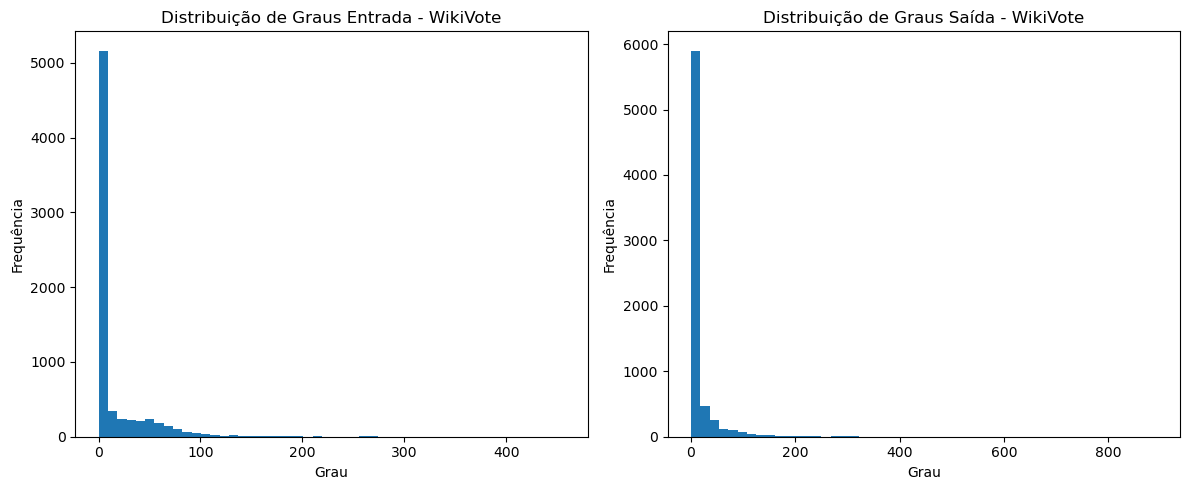

In [13]:
fig, axs = plt.subplots(1,2, figsize=(12,5))

axs[0].hist(indegrees, bins=50)
axs[0].set_xlabel("Grau")
axs[0].set_ylabel("Frequência")
axs[0].set_title("Distribuição de Graus Entrada - WikiVote")

axs[1].hist(outdegrees, bins=50)
axs[1].set_xlabel("Grau")
axs[1].set_ylabel("Frequência")
axs[1].set_title("Distribuição de Graus Saída - WikiVote")

plt.tight_layout()
plt.show()

# Lei de Potência na Distribuição de Graus

Em muitas redes complexas a distribuição de graus segue uma **Lei de Potência**.

Essa distribuição é representada pela equação:

P(k) ~ k^-α

onde:

- **k** representa o grau do vértice
- **α (alpha)** representa o expoente da distribuição
- **xmin** representa o valor mínimo a partir do qual os dados passam a seguir aproximadamente a distribuição de lei de potência.
Quando:

2 < α < 3 segue a lei de potencia


## Resultados Obtidos

A análise produziu os seguintes valores:

**Grau de saída (Outdegree)**  
- α ≈ 1.53  
- xmin = 1

**Grau de entrada (Indegree)**  
- α ≈ 2.98  
- xmin = 44

---

## Interpretação

O valor de **α ≈ 1.53 para o grau de saída** indica uma distribuição bastante concentrada, onde poucos usuários realizam muitos votos enquanto a maioria realiza poucos votos.

Já para o **grau de entrada**, o valor **α ≈ 2.98** está próximo do intervalo frequentemente observado em redes complexas (entre 2 e 3). Isso sugere que existem alguns usuários que recebem muitos votos, funcionando como **hubs da rede**.

O valor **xmin = 44** indica que o comportamento de lei de potência passa a ocorrer apenas a partir de vértices com grau de entrada relativamente alto.

A rede apresenta características típicas de redes complexas, com presença de **vértices altamente conectados**, porém o comportamento de lei de potência é mais evidente na distribuição de **grau de entrada** do que no grau de saída.

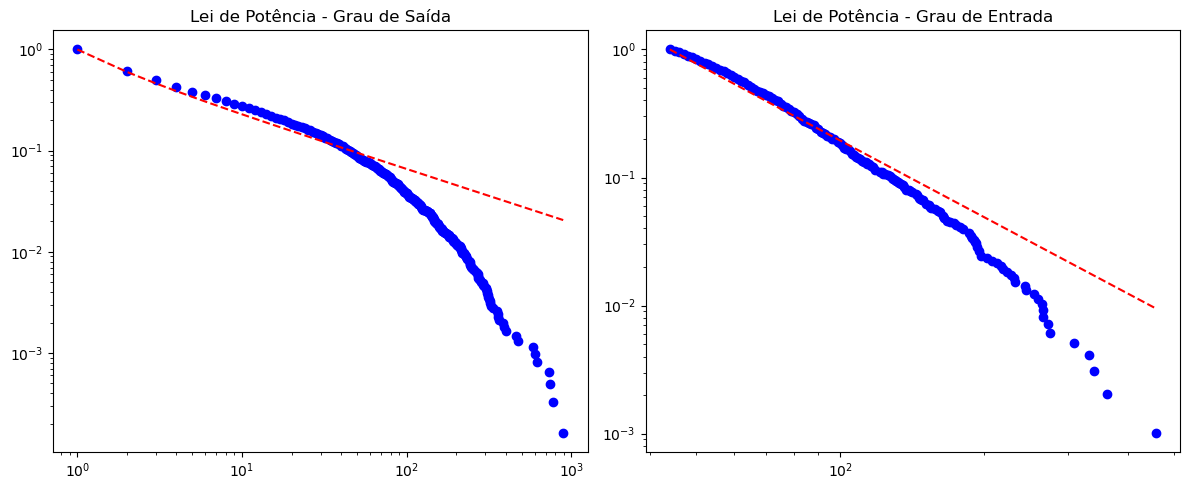

Alpha outdegrees: 1.5299660828606068
xmin outdegrees: 1.0
Alpha indegrees: 2.9805102629586657
xmin indegrees: 44.0


In [11]:
fig, axs = plt.subplots(1,2, figsize=(12,5))

fitOut = powerlaw.Fit(outdegrees, discrete=True, verbose=False)
fitOut.plot_ccdf(ax=axs[0], color='blue', marker='o', linestyle='None')
fitOut.power_law.plot_ccdf(ax=axs[0], color='red', linestyle='--')

axs[0].set_title("Lei de Potência - Grau de Saída")

fitIn = powerlaw.Fit(indegrees, discrete=True, verbose=False)
fitIn.plot_ccdf(ax=axs[1], color='blue', marker='o', linestyle='None')
fitIn.power_law.plot_ccdf(ax=axs[1], color='red', linestyle='--')

axs[1].set_title("Lei de Potência - Grau de Entrada")

plt.tight_layout()
plt.show()

print("Alpha outdegrees:", fitOut.power_law.alpha)
print("xmin outdegrees:", fitOut.power_law.xmin)

print("Alpha indegrees:", fitIn.power_law.alpha)
print("xmin indegrees:", fitIn.power_law.xmin)

# Conclusão

A análise da rede WikiVote permitiu observar diversas características típicas de redes sociais complexas.

O grafo analisado possui **7115 usuários e 103689 votos**, representando uma rede relativamente grande de interações entre membros da comunidade da Wikipédia.

A densidade encontrada (**0.002049**) indica que a rede é **bastante esparsa**, ou seja, apenas uma pequena fração das conexões possíveis realmente ocorre. Isso é esperado em redes sociais, pois cada usuário interage apenas com uma pequena parte da rede total.

Também foi observado que a maioria dos usuários possui pouca participação direta nas votações, já que **4734 usuários não receberam nenhum voto** e **1005 usuários não votaram em ninguém**.

Por outro lado, alguns usuários apresentam grau extremamente alto, como **893 votos realizados** e **457 votos recebidos**, indicando a presença de vértices altamente conectados, conhecidos como **hubs**.

A análise da distribuição de graus mostrou que as conexões estão distribuídas de forma **heterogênea**, onde poucos usuários concentram grande parte das interações enquanto a maioria possui poucas conexões.

Esse comportamento é comum em redes sociais reais e sistemas colaborativos online, onde a atividade e a visibilidade dos usuários são naturalmente desiguais.

Dessa forma, a análise realizada demonstra como técnicas de **teoria dos grafos e ciência de redes** podem ser utilizadas para compreender a estrutura e o comportamento de sistemas complexos baseados em interação entre usuários.



<img src="graph.jpeg" width="50100">
